In [1]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')

file_path = "/content/drive/My Drive/Bank ML Project/House_Price_India.csv"

df = pd.read_csv(file_path)

df.head()


Mounted at /content/drive


,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [12]:
# Step 1: Advanced Feature Engineering
X = df.drop(columns=["Price"])
y = df["Price"]

# Drop the 'id' and 'Date' columns first
X = X.drop(columns=["id", "Date"])

# Define the current year for age calculation
current_year = 2025

# Calculate age based on built year and age since renovation
age_built = current_year - X['Built Year']
age_renovated = current_year - X['Renovation Year']

# If Renovation Year is 0, use age_built.
# Otherwise, use the average of age_built and age_renovated.
X['house_age'] = np.where(
    X['Renovation Year'] == 0,
    age_built,
    (age_built + age_renovated) / 2
)

# Now drop the original year columns
X = X.drop(columns=['Built Year', 'Renovation Year'])


# --- Step 2: Split and Re-train ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Train Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Step 5: Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Absolute Error (MAE): ₹{mae:,.2f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): ₹96,122.89
R² Score: 0.7877


In [15]:
# Define the hyperparameter grid
param_grid = {
    "max_depth": [5, 10, 15, None],  # Try limiting tree depth
    "min_samples_split": [2, 5, 10],  # Minimum samples to split a node
    "min_samples_leaf": [1, 2, 5]  # Minimum samples in a leaf node
}

# Initialize Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best model and parameters
best_dt_model = grid_search.best_estimator_
best_dt_params = grid_search.best_params_

# Make predictions using the best model
y_pred_dt_best = best_dt_model.predict(X_test)

# Evaluate the best model
mae_dt_best = mean_absolute_error(y_test, y_pred_dt_best)
r2_dt_best = r2_score(y_test, y_pred_dt_best)

# Print results
print(f"Best Decision Tree Parameters: {best_dt_params}")
print(f"Optimized Mean Absolute Error (MAE): ₹{mae_dt_best:,.2f}")
print(f"Optimized R² Score: {r2_dt_best:.4f}")


Best Decision Tree Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Optimized Mean Absolute Error (MAE): ₹91,910.64
Optimized R² Score: 0.7933


In [17]:
# Define a smaller hyperparameter grid
param_dist_rf = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Initialize Random Forest
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

# Use Randomized Search (faster than GridSearchCV)
random_search_rf = RandomizedSearchCV(
    rf_model, param_dist_rf,
    n_iter=5,  # Try only 5 random combinations
    cv=3,  # 3-fold CV instead of 5 (reduces computation)
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,  # Monitor progress
    random_state=42
)

# Train the model with Randomized Search
random_search_rf.fit(X_train, y_train)

# Get best model and parameters
best_rf_model = random_search_rf.best_estimator_
best_rf_params = random_search_rf.best_params_

# Make predictions
y_pred_rf_best = best_rf_model.predict(X_test)

# Evaluate performance
mae_rf_best = mean_absolute_error(y_test, y_pred_rf_best)
r2_rf_best = r2_score(y_test, y_pred_rf_best)

# Print results
print(f"Best Random Forest Parameters: {best_rf_params}")
print(f"Optimized Random Forest MAE: ₹{mae_rf_best:,.2f}")
print(f"Optimized Random Forest R² Score: {r2_rf_best:.4f}")


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Random Forest Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
Optimized Random Forest MAE: ₹69,313.76
Optimized Random Forest R² Score: 0.8703


/tmp/ipython-input-1868567528.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance_df["Importance"], y=feat_importance_df["Feature"], palette="viridis")


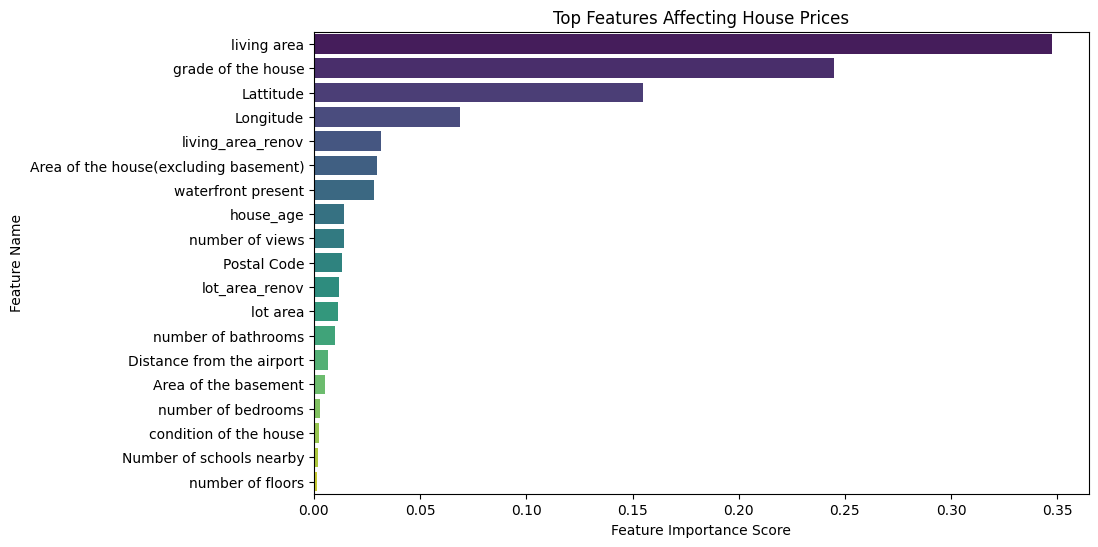

In [18]:
# Get feature importances from the best Random Forest model
feature_importances = best_rf_model.feature_importances_

# Create a DataFrame with feature names and their importance scores
feat_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by="Importance", ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance_df["Importance"], y=feat_importance_df["Feature"], palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Name")
plt.title("Top Features Affecting House Prices")
plt.show()


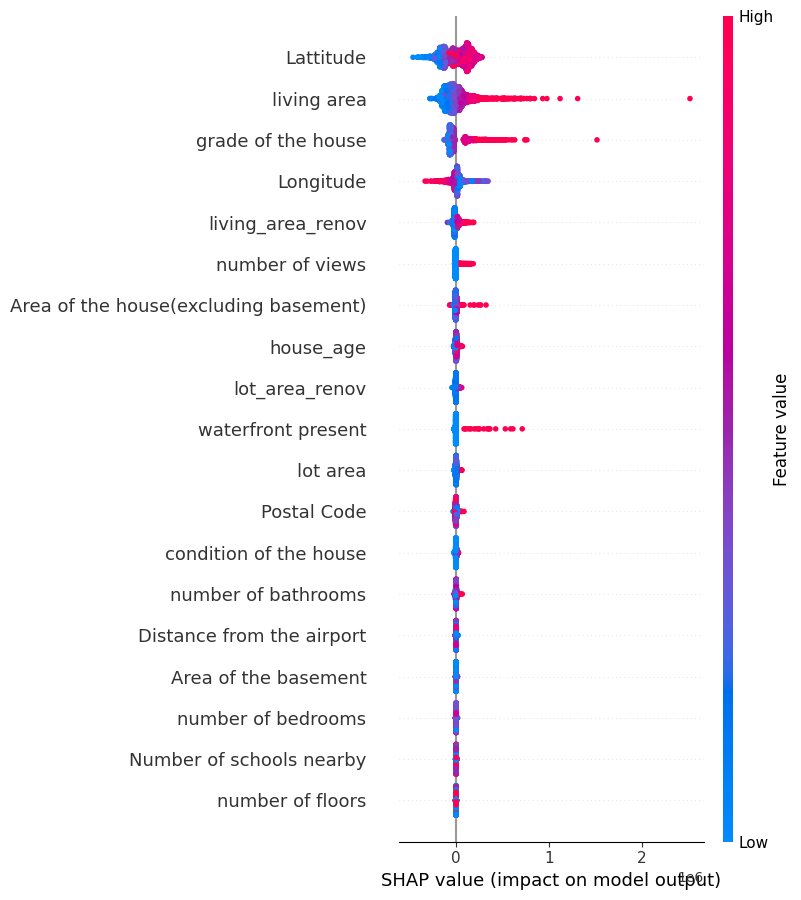

In [19]:
import shap

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(best_rf_model)

# Compute SHAP values with additivity check disabled
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Summary Plot (Global Feature Importance)
shap.summary_plot(shap_values, X_test)


# Linear Regression Model

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize and Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate Model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Print Results
print(f"Linear Regression MAE: ₹{mae_lr:,.2f}")
print(f"Linear Regression R² Score: {r2_lr:.4f}")

# Interpret Coefficients
coefficients = pd.DataFrame({"Feature": X.columns, "Coefficient": lr_model.coef_})
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

# Display Feature Importance
print("\nFeature Impact on Price (Linear Regression):")
print(coefficients)


Linear Regression MAE: ₹125,773.86
Linear Regression R² Score: 0.7160

Feature Impact on Price (Linear Regression):
                                  Feature    Coefficient
5                      waterfront present  589910.988033
12                              Lattitude  549663.173329
8                      grade of the house   94597.863505
6                         number of views   48004.358187
1                     number of bathrooms   44745.606697
7                  condition of the house   26924.189511
18                              house_age    2564.510446
16               Number of schools nearby    1977.967045
11                            Postal Code     305.433000
2                             living area     117.241630
9   Area of the house(excluding basement)      80.317736
10                   Area of the basement      36.923894
14                      living_area_renov      16.172139
3                                lot area      -0.064316
15                         lo

In [27]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Create a Preprocessing Pipeline

# Identify categorical and numerical features
# We treat 'Postal Code' as a category
categorical_features = ['Postal Code']
numerical_features = X.drop(columns=categorical_features).columns

# Create the preprocessing steps for both feature types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),  # Scale numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # One-Hot Encode categorical
    ])

# Create and Train the Full Pipeline with Ridge Regression
# The pipeline will first preprocess the data, then train the Ridge model
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', Ridge(alpha=1.0))])  # alpha is the regularization strength

ridge_pipeline.fit(X_train, y_train)

# Evaluate the Improved Model
y_pred_ridge = ridge_pipeline.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Improved Linear Model (Ridge Regression) Performance")
print(f"Ridge Regression MAE: ₹{mae_ridge:,.2f}")
print(f"Ridge Regression R² Score: {r2_ridge:.4f}")

# Interpret Coefficients
coefficients = pd.DataFrame({"Feature": X.columns, "Coefficient": lr_model.coef_})
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

# Display Feature Importance
print("\nFeature Impact on Price (Linear Regression):")
print(coefficients)

Improved Linear Model (Ridge Regression) Performance
Ridge Regression MAE: ₹95,105.98
Ridge Regression R² Score: 0.8313

Feature Impact on Price (Linear Regression):
                                  Feature    Coefficient
5                      waterfront present  589910.988033
12                              Lattitude  549663.173329
8                      grade of the house   94597.863505
6                         number of views   48004.358187
1                     number of bathrooms   44745.606697
7                  condition of the house   26924.189511
18                              house_age    2564.510446
16               Number of schools nearby    1977.967045
11                            Postal Code     305.433000
2                             living area     117.241630
9   Area of the house(excluding basement)      80.317736
10                   Area of the basement      36.923894
14                      living_area_renov      16.172139
3                                lot

# XGBoost

In [30]:
import xgboost as xgb

# Initialize and Train the XGBoost Model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=100,
                             learning_rate=0.1,
                             max_depth=5,
                             random_state=42,
                             n_jobs=-1)

xgb_model.fit(X_train, y_train)

# Make Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the Model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("--- Baseline XGBoost Model Performance ---")
print(f"XGBoost MAE: ₹{mae_xgb:,.2f}")
print(f"XGBoost R² Score: {r2_xgb:.4f}")

--- Baseline XGBoost Model Performance ---
XGBoost MAE: ₹67,097.52
XGBoost R² Score: 0.8964


In [31]:
# Define a hyperparameter grid for XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Initialize the XGBRegressor
xgb_model_for_tuning = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Set up Randomized Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model_for_tuning,
    param_distributions=param_dist_xgb,
    n_iter=50, # Try 50 random combinations
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_search_xgb.fit(X_train, y_train)

# Get the best model and parameters
best_xgb_model = random_search_xgb.best_estimator_
best_xgb_params = random_search_xgb.best_params_

# Evaluate the new best model
y_pred_xgb_best = best_xgb_model.predict(X_test)
mae_xgb_best = mean_absolute_error(y_test, y_pred_xgb_best)
r2_xgb_best = r2_score(y_test, y_pred_xgb_best)

print("\n--- Tuned XGBoost Model Performance ---")
print(f"Best XGBoost Parameters Found: {best_xgb_params}")
print(f"Tuned XGBoost MAE: ₹{mae_xgb_best:,.2f}")
print(f"Tuned XGBoost R² Score: {r2_xgb_best:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Tuned XGBoost Model Performance ---
Best XGBoost Parameters Found: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Tuned XGBoost MAE: ₹62,435.86
Tuned XGBoost R² Score: 0.9074


Top 10 Most Important Features:
                                  Feature  Importance
8                      grade of the house    0.355836
5                      waterfront present    0.185377
2                             living area    0.155654
12                              Lattitude    0.066345
6                         number of views    0.044089
13                              Longitude    0.037631
14                      living_area_renov    0.022537
9   Area of the house(excluding basement)    0.022316
1                     number of bathrooms    0.021398
11                            Postal Code    0.021036


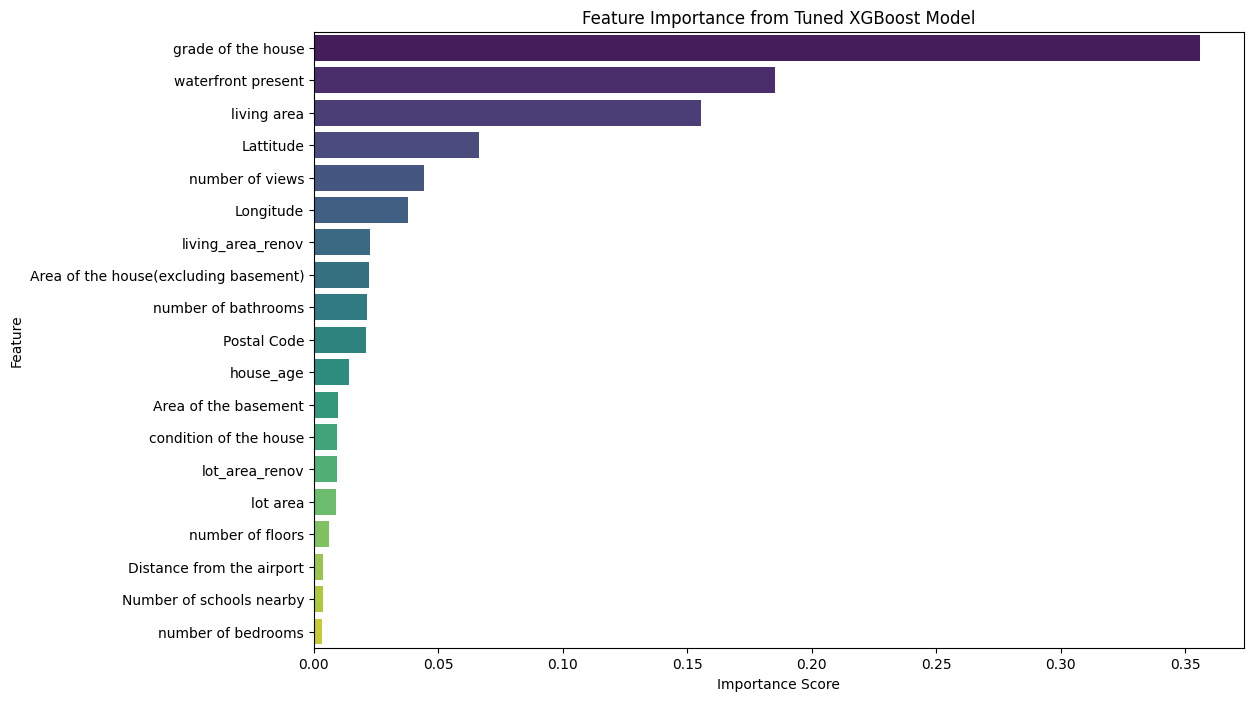

In [34]:
# Get feature importances
importances = best_xgb_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame to store features and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print the top 10 most important features
print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))


# Visualize the feature importances
plt.figure(figsize=(12, 8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Feature Importance from Tuned XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.savefig('xgboost_feature_importance_colored.png')
plt.show()

Generating SHAP Summary Plot...


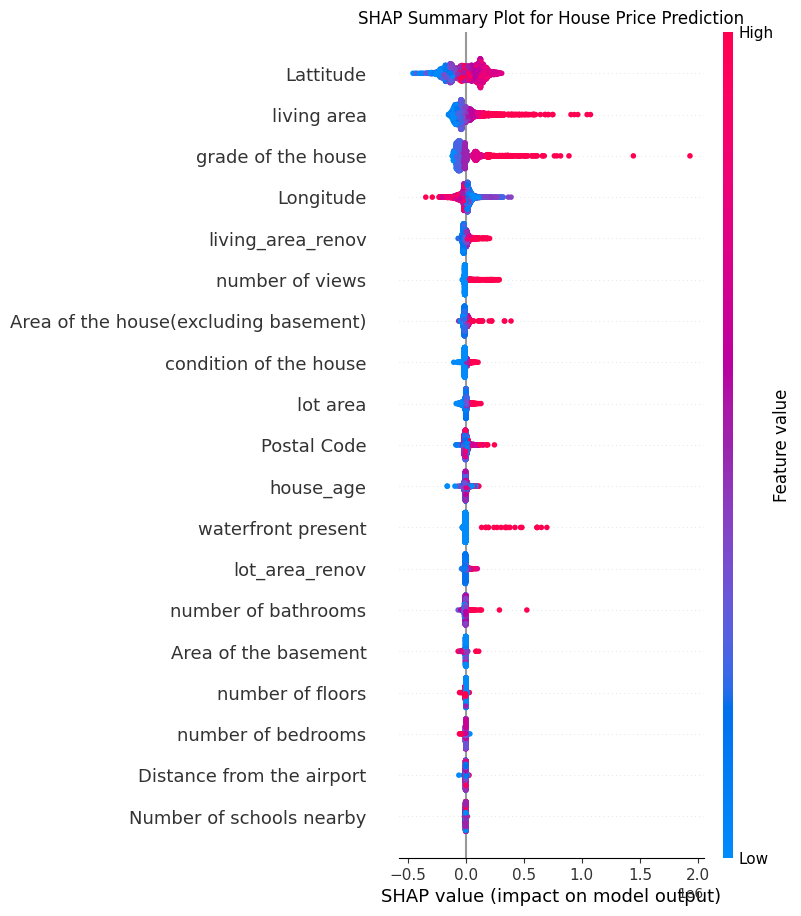

In [35]:
# Create the SHAP explainer and calculate SHAP values
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

# Create the SHAP summary plot (beeswarm plot)
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test, show=False)

# Add a title to the plot
plt.title('SHAP Summary Plot for House Price Prediction')
plt.savefig('shap_summary_plot.png')
plt.show()